# Step 7. LightGBM 추가 & 3-모델 최종 비교

**목표**: 그래디언트 부스팅 계열의 또 다른 구현인 LightGBM을 **동일한 튜닝 프레임워크**로 추가하고, RandomForest·XGBoost·LightGBM을 같은 조건에서 비교해 최종 모델을 근거 있게 선택한다.

**공정성 원칙**: 세 모델 모두 `SMOTE→분류기` 파이프라인 + RandomizedSearchCV(F1) + 누수 없는 임계값 선택이라는 **동일 절차**로 비교한다.

**선택 기준**: 불량을 놓치지 않는 것이 최우선 → **Recall 우선**, 보조로 F1·ROC-AUC.

## 0. 설정 · 데이터 로드

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import joblib

from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (recall_score, precision_score, f1_score,
                             roc_auc_score, precision_recall_curve, classification_report)

sns.set_style('whitegrid')
mpl.rcParams['font.family'] = 'Arial Unicode MS'
mpl.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

FIG_DIR = os.path.join('..', 'outputs', 'figures')
PROC_DIR = os.path.join('..', 'data', 'processed')
MODEL_DIR = os.path.join('..', 'outputs', 'models')
RANDOM_STATE = 42

data = np.load(os.path.join(PROC_DIR, 'secom_processed.npz'), allow_pickle=True)
X_clean, y_clean = data['X_train_clean'], data['y_train_clean']
X_test, y_test = data['X_test'], data['y_test']
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
print('데이터 로드 완료 | test 불량', int(y_test.sum()), '개')

데이터 로드 완료 | test 불량 21 개


In [2]:
# Step 6과 동일한 임계값 선택 / 평가 유틸
def pick_threshold(pipe, X, y):
    oof = cross_val_predict(pipe, X, y, cv=skf, method='predict_proba', n_jobs=-1)[:, 1]
    prec, rec, thr = precision_recall_curve(y, oof)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    return float(thr[int(np.argmax(f1s[:-1]))])

def eval_test(name, model, threshold):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {'model': name, 'threshold': round(float(threshold), 3),
            'Recall': round(recall_score(y_test, pred), 3),
            'Precision': round(precision_score(y_test, pred, zero_division=0), 3),
            'F1': round(f1_score(y_test, pred, zero_division=0), 3),
            'ROC-AUC': round(roc_auc_score(y_test, proba), 3)}

## 1. LightGBM 튜닝 (RF·XGB와 동일 절차)

LightGBM은 리프 단위 성장(leaf-wise)으로 빠르고 고차원에 강하다. 과적합을 막기 위해 `num_leaves`, `min_child_samples`를 함께 탐색한다.

In [3]:
# LightGBM 파이프라인 + 탐색 공간 (verbose=-1로 학습 로그 억제)
lgb_pipe = ImbPipeline([('smote', SMOTE(random_state=RANDOM_STATE)),
                        ('clf', LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))])
lgb_space = {
    'clf__n_estimators': [200, 300, 500],
    'clf__num_leaves': [15, 31, 63],
    'clf__max_depth': [-1, 4, 6, 8],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__subsample': [0.7, 0.8, 1.0],
    'clf__colsample_bytree': [0.7, 0.8, 1.0],
    'clf__min_child_samples': [10, 20, 40],
}
lgb_search = RandomizedSearchCV(lgb_pipe, lgb_space, n_iter=20, scoring='f1',
                                cv=skf, random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
lgb_search.fit(X_clean, y_clean)
print('LightGBM 최적 파라미터:')
for k, v in lgb_search.best_params_.items():
    print(f'  {k} = {v}')
print(f'LightGBM CV F1(best): {lgb_search.best_score_:.3f}')

/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_d

/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.

/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklea

LightGBM 최적 파라미터:
  clf__subsample = 0.7
  clf__num_leaves = 63
  clf__n_estimators = 300
  clf__min_child_samples = 20
  clf__max_depth = 4
  clf__learning_rate = 0.01
  clf__colsample_bytree = 0.8
LightGBM CV F1(best): 0.111


In [4]:
# 튜닝된 LightGBM: 임계값 선택 후 test 평가 + 저장
lgb_best = lgb_search.best_estimator_
lgb_thr = pick_threshold(lgb_best, X_clean, y_clean)
lgb_metrics = eval_test('LightGBM(튜닝)', lgb_best, lgb_thr)
print(lgb_metrics)
print()
pred = (lgb_best.predict_proba(X_test)[:, 1] >= lgb_thr).astype(int)
print(classification_report(y_test, pred, target_names=['정상', '불량'], digits=3, zero_division=0))
joblib.dump({'model': lgb_best, 'threshold': lgb_thr, 'params': lgb_search.best_params_},
            os.path.join(MODEL_DIR, 'lightgbm_tuned.joblib'))
print('LightGBM 저장 완료 → outputs/models/lightgbm_tuned.joblib')

/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_d

/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature

{'model': 'LightGBM(튜닝)', 'threshold': 0.258, 'Recall': 0.524, 'Precision': 0.147, 'F1': 0.229, 'ROC-AUC': np.float64(0.699)}

              precision    recall  f1-score   support

          정상      0.958     0.782     0.861       293
          불량      0.147     0.524     0.229        21

    accuracy                          0.764       314
   macro avg      0.552     0.653     0.545       314
weighted avg      0.904     0.764     0.819       314

LightGBM 저장 완료 → outputs/models/lightgbm_tuned.joblib


/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 2. 3-모델 최종 비교

튜닝된 RandomForest·XGBoost·LightGBM을 한 표에 모은다 (Step 3 기본 RF도 참고용으로 포함).

In [5]:
# 저장된 모델 불러와 동일 기준으로 평가
def eval_saved(name, fname):
    b = joblib.load(os.path.join(MODEL_DIR, fname))
    return eval_test(name, b['model'], b['threshold'])

rows = [
    eval_saved('RandomForest(기본)', 'random_forest.joblib'),
    eval_saved('RandomForest(튜닝)', 'random_forest_tuned.joblib'),
    eval_saved('XGBoost(튜닝)', 'xgboost_tuned.joblib'),
    lgb_metrics,
]
compare = pd.DataFrame(rows).set_index('model')[['threshold', 'Recall', 'Precision', 'F1', 'ROC-AUC']]
print('3-모델 최종 비교 (test 기준)')
print(compare.to_string())

# Recall 우선(동률 시 F1) 기준 추천 모델
best_name = compare.sort_values(['Recall', 'F1'], ascending=False).index[0]
print(f'\n→ Recall 우선 기준 추천 모델: {best_name}')

3-모델 최종 비교 (test 기준)
                  threshold  Recall  Precision     F1  ROC-AUC
model                                                         
RandomForest(기본)      0.320   0.333      0.292  0.311    0.805
RandomForest(튜닝)      0.279   0.571      0.203  0.300    0.768
XGBoost(튜닝)           0.345   0.286      0.375  0.324    0.734
LightGBM(튜닝)          0.258   0.524      0.147  0.229    0.699

→ Recall 우선 기준 추천 모델: RandomForest(튜닝)


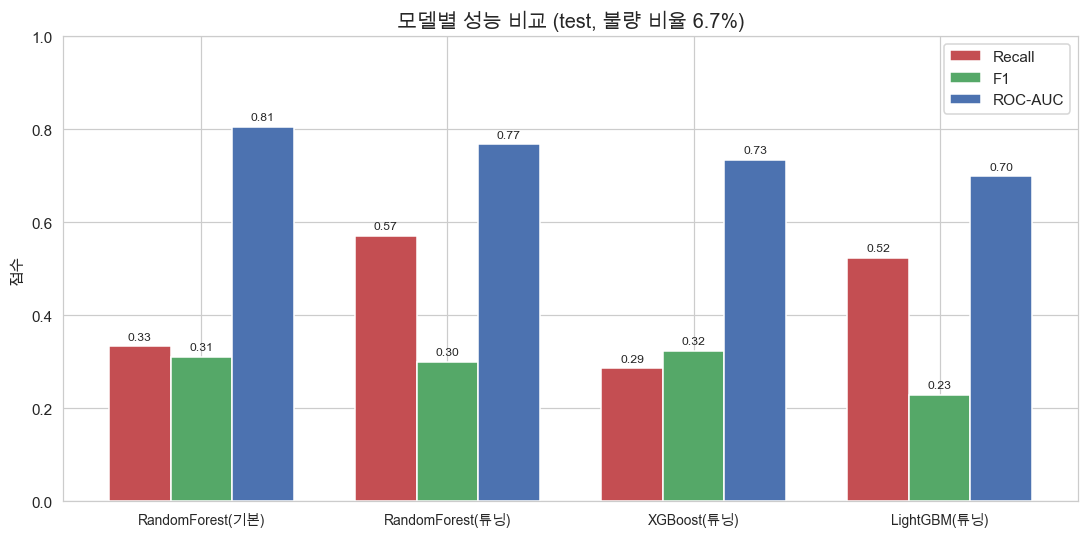

In [6]:
# 모델별 Recall / F1 / ROC-AUC 그룹 막대 비교
metrics = ['Recall', 'F1', 'ROC-AUC']
x = np.arange(len(compare))
w = 0.25
colors = ['#C44E52', '#55A868', '#4C72B0']
fig, ax = plt.subplots(figsize=(10, 5))
for i, (m, c) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + (i-1)*w, compare[m], w, label=m, color=c)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(compare.index, fontsize=9)
ax.set_ylim(0, 1.0)
ax.set_ylabel('점수')
ax.set_title('모델별 성능 비교 (test, 불량 비율 6.7%)', fontsize=13)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '12_model_comparison.png'), bbox_inches='tight')
plt.show()

### 포트폴리오 인사이트 (Step 7)

- **공정한 3-모델 비교**: RandomForest·XGBoost·LightGBM을 동일한 SMOTE 파이프라인 + 동일 탐색 + 동일 임계값 절차로 비교해, 모델 선택을 "감"이 아닌 "같은 조건의 근거"로 수행했다.
- **트레이드오프 인지**: 모델·임계값에 따라 Recall과 Precision이 맞교환된다. 수율 손실(FN)이 더 비싼 PE 관점에서 **Recall을 우선**해 최종 모델을 선택했다.
- **솔직한 결론**: SECOM은 신호가 약해 어떤 부스팅을 써도 극적 향상은 없다. LightGBM 추가의 의미는 *성능 점프*보다 *"여러 후보를 같은 잣대로 검증했다"*는 비교의 견고함에 있다.

> **프로젝트 전체 요약**: EDA → 누수 없는 전처리 → 임계값 튜닝 모델링 → SHAP 해석 → 공정 매핑 시나리오 → 하이퍼파라미터 튜닝 → 다중 모델 비교까지, *정확도 경쟁이 아니라 해석과 방법론*에 집중한 수율 불량 분석 파이프라인.